# 暗い画像をただ明るくしない: ICDで色とノイズの扱いはどう変わるのか試す

この notebook は、技術ブログ記事「暗い画像をただ明るくしない: ICDで色とノイズの扱いはどう変わるのか試す」の再現用コードです。

低照度画像補正を、単に暗いRGB画像を明るいRGB画像へ写す処理としてだけ見ず、**Intensity（明るさの包絡）** と **Chromaticity（RGBチャンネル間の比率）** に分けると何が見えるのかを確認します。

比較する方法は次の5つです。

| 方法 | 役割 | この notebook での位置づけ |
|---|---|---|
| `input` | 元画像 | 低照度画像の例 |
| `gamma` | ガンマ補正 + gain | 画像全体を素直に明るくするベースライン |
| `clahe` | LabのLチャンネルにCLAHE | 局所コントラストを上げる古典的手法 |
| `retinex` | 簡易Multi-Scale Retinex | 照明成分を補正する古典的発想の例 |
| `icd_inspired` | Intensity/Chromaticity分解の簡易実装 | ICD論文の考え方を可視化する説明用 |
| `official_icd` | 公式ICDNet推論 | 学習済みモデルを使った任意比較 |

> `icd_inspired` は論文モデルの再実装ではありません。  
> `Intensity = max(R, G, B)` と `Chromaticity = log(RGB / Intensity)` という分解の直感を、記事中で説明しやすくするための簡易実装です。論文モデルそのものの結果は、後半の「公式 ICDNet を実行する」セルで扱います。

## 参考リンク

- 論文: [Rethinking Low-Light Image Enhancement: A Log-Domain Intensity--Chromaticity Decoupling Perspective](https://arxiv.org/abs/2605.02627)  
  2026-05-04公開の arXiv:2605.02627v1 を参照しました。低照度画像補正を直接のRGB-to-RGB変換としてではなく、log-domain の intensity と chromaticity に分けて扱う論文です。
- 公式実装: [mubaisam/ICD](https://github.com/mubaisam/ICD)  
  READMEでは `test.py` による直接推論、`eval.py` によるPSNR/SSIM/LPIPS評価、checkpoint指定などが説明されています。
- 使用画像: [Pexels Photo 3185041](https://www.pexels.com/photo/black-metal-window-frame-3185041/)  
  暗い階段室と明るい窓が同時に写っており、暗部補正、白飛び、色の安定性を比較しやすい画像です。写真作者は Ekaterina Astakhova です。
- ライセンス: [Pexels License](https://www.pexels.com/license/)  
  Pexelsの利用条件を確認し、公開時には画像の出典とライセンスURLを併記します。


## 0. 画像の準備

入力画像は `images/input/` に置きます。この notebook では、次の画像を使用しています。

- 入力画像: `images/input/pexels-octoptimist-3185041.jpg`
- 出典: [Pexels Photo 3185041](https://www.pexels.com/photo/black-metal-window-frame-3185041/)
- Photographer: Ekaterina Astakhova
- License: [Pexels License](https://www.pexels.com/license/)

この画像は、暗い階段室の中に明るい窓があるため、次の観点を見比べやすいです。

```text
暗部をどこまで持ち上げられるか
窓や明るい壁を白飛びさせないか
手すりや壁の色が不自然にならないか
暗部のノイズや色ムラが目立たないか
```

別の画像で試す場合は、同じディレクトリに `.jpg` / `.png` / `.webp` などを追加してください。


In [1]:
# 必要ライブラリ
!pip install -q opencv-python pillow matplotlib numpy scikit-image tqdm


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [15]:
import sys
import subprocess
from pathlib import Path

import os
import shutil
import math
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

INPUT_DIR = Path("images/input")
OUT_DIR = Path("images/output")
GRID_DIR = Path("images/grids")
CROP_DIR = Path("images/crops")

for d in [INPUT_DIR, OUT_DIR, GRID_DIR, CROP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted([p for p in INPUT_DIR.iterdir() if p.suffix.lower() in image_exts])

print(f"Found {len(image_paths)} images in {INPUT_DIR.resolve()}")
for p in image_paths:
    print("-", p)


Found 1 images in /work/write_blog/images/input
- images/input/pexels-octoptimist-3185041.jpg


In [3]:
def read_rgb(path: Path) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    arr = np.asarray(img).astype(np.float32) / 255.0
    return arr

def save_rgb(path: Path, img: np.ndarray):
    path.parent.mkdir(parents=True, exist_ok=True)
    img = np.clip(img, 0, 1)
    Image.fromarray((img * 255 + 0.5).astype(np.uint8)).save(path)

def show_img(img, title=None, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(np.clip(img, 0, 1))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def rgb_to_uint8(img):
    return (np.clip(img, 0, 1) * 255 + 0.5).astype(np.uint8)

def luminance(img):
    # Rec.709 luma
    return 0.2126 * img[..., 0] + 0.7152 * img[..., 1] + 0.0722 * img[..., 2]

def percentile_stretch(img, low=1, high=99):
    out = np.empty_like(img)
    if img.ndim == 2:
        lo, hi = np.percentile(img, [low, high])
        out = (img - lo) / (hi - lo + 1e-8)
        return np.clip(out, 0, 1)
    for c in range(img.shape[-1]):
        lo, hi = np.percentile(img[..., c], [low, high])
        out[..., c] = (img[..., c] - lo) / (hi - lo + 1e-8)
    return np.clip(out, 0, 1)


## 1. 比較手法の実装

ここでは、記事で並べて見せるための補正処理を実装します。

古典的な補正方法は、処理内容が分かりやすい一方で、暗部を持ち上げるほどノイズ、色ズレ、白飛びも目立ちやすくなります。ICDの発想を理解するために、まずはこの「ただ明るくすることの難しさ」が見える比較対象を用意します。

### 1.1 Gamma / Exposure 補正

ガンマ補正と gain で、画像全体を素直に明るくするベースラインです。

暗部は見えやすくなりますが、明るい窓や壁も同時に持ち上がるため、白飛びや灰色っぽさが出やすくなります。低照度補正を「とりあえず明るくする」と考えた場合の代表例として使います。


In [4]:
def gamma_exposure(img, gamma=0.55, gain=1.15):
    # gamma < 1 で暗部を持ち上げる
    out = np.power(np.clip(img, 0, 1), gamma) * gain
    return np.clip(out, 0, 1)


### 1.2 CLAHE

CLAHE（Contrast Limited Adaptive Histogram Equalization）は、局所的なヒストグラム補正でコントラストを上げる方法です。

ここではRGBを直接いじらず、Lab色空間の `L` チャンネルだけにCLAHEを適用します。色チャンネルへの影響を抑えながら局所コントラストを上げるためです。

今回の設定では、画像全体を大きく明るくするというより、暗さを残したまま局所的な差を少し強める結果になります。強くかけると質感が人工的になりやすいので、比較用として控えめな設定にしています。


In [5]:
def clahe_lab(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    img8 = rgb_to_uint8(img)
    lab = cv2.cvtColor(img8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    lab2 = cv2.merge([l2, a, b])
    out = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB).astype(np.float32) / 255.0
    return np.clip(out, 0, 1)


### 1.3 Multi-Scale Retinex

Retinexは、画像を照明成分と反射率成分に分けて考える古典的な発想です。

この notebook では、複数スケールのガウシアンぼかしを使った簡易的な Multi-Scale Retinex を実装します。厳密な論文再現やチューニング済み実装ではなく、記事中で「照明を補正する古典的な考え方」と比較するための実装です。

Retinexは暗部を強く見えるようにしやすい一方で、設定によっては全体が白っぽくなったり、局所的な色の違和感が出たりします。この notebook では、そのトレードオフを見るために入れています。


In [6]:
def multi_scale_retinex(img, sigmas=(15, 80, 250), low=1, high=99):
    eps = 1e-6
    img = np.clip(img, eps, 1.0)
    retinex = np.zeros_like(img)
    for sigma in sigmas:
        blur = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma, sigmaY=sigma)
        retinex += np.log(img + eps) - np.log(blur + eps)
    retinex /= len(sigmas)

    # チャンネルごとに見やすい範囲へ正規化
    out = percentile_stretch(retinex, low=low, high=high)
    return np.clip(out, 0, 1)


### 1.4 ICD発想の簡易実装

ここで実装する `icd_inspired_enhance` は、ICDNetそのものではありません。論文の中心にある「RGBをそのまま補正するのではなく、明るさと色比率を分ける」という考え方を可視化するための説明用コードです。

処理の流れは次の通りです。

```text
1. Intensity = max(R, G, B) として明るさの包絡を作る
2. Chromaticity = log(RGB / Intensity) としてチャンネル比率を作る
3. Intensity をガンマ補正で持ち上げる
4. 暗すぎる場所では Chromaticity を信用しすぎないよう gate で弱める
5. RGB = Intensity * exp(Chromaticity) で戻す
```

暗部のRGB値は信号が弱く、色比率そのものもノイズの影響を受けやすくなります。そのため、この簡易実装では暗部の chromaticity を弱め、色ノイズの増幅を抑える方向にしています。

ただし、その分だけ暗部の色や明るさは保守的になり、黒く残りやすくなります。これは公式ICDNetの性能を示すものではなく、あくまで分解発想を理解するための小さな実験です。


In [7]:
def icd_inspired_enhance(
    img,
    gamma=0.50,
    gain=1.10,
    dark_threshold=0.16,
    gate_sharpness=28.0,
    min_chroma_strength=0.35,
    stretch_intensity=True,
):
    eps = 1e-6
    img = np.clip(img, 0, 1)

    # 1. intensity envelope
    I = np.max(img, axis=-1, keepdims=True)
    I_safe = np.maximum(I, eps)

    # 2. log-domain chromaticity
    C = np.log((img + eps) / I_safe)

    # zero-anchor: 最大チャンネルが 0 になるように補正
    C = C - np.max(C, axis=-1, keepdims=True)
    C = np.minimum(C, 0.0)

    # 3. intensity recovery
    I2 = np.power(np.clip(I, 0, 1), gamma) * gain
    if stretch_intensity:
        I2 = percentile_stretch(I2.squeeze(-1), low=0.5, high=99.5)[..., None]
    I2 = np.clip(I2, 0, 1)

    # 4. chromaticity confidence gate
    # 明るいところ: gate ≒ 1 → 色比率を保つ
    # 暗すぎるところ: gate ≒ 0 → 色比率を弱める
    gate = 1.0 / (1.0 + np.exp(-gate_sharpness * (I - dark_threshold)))
    chroma_strength = min_chroma_strength + (1.0 - min_chroma_strength) * gate
    C2 = C * chroma_strength

    # 再度 feasible domain へ
    C2 = C2 - np.max(C2, axis=-1, keepdims=True)
    C2 = np.minimum(C2, 0.0)

    # 5. constrained reconstruction
    out = I2 * np.exp(C2)
    return np.clip(out, 0, 1)

def visualize_icd_components(img):
    eps = 1e-6
    I = np.max(img, axis=-1)
    C = np.log((img + eps) / np.maximum(I[..., None], eps))
    C = C - np.max(C, axis=-1, keepdims=True)
    C_vis = percentile_stretch(C, 1, 99)
    return I, C_vis


## 2. 画像を一括処理して比較グリッドを作る

`images/input/` 内の画像に対して、`input` / `gamma` / `clahe` / `retinex` / `icd_inspired` をまとめて適用します。

出力先は次の通りです。

| 出力 | 保存先 |
|---|---|
| 各手法の個別画像 | `images/output/{method}/` |
| 比較グリッド | `images/grids/{image_stem}_grid.png` |

記事の「結果1: 画像全体での比較」には、ここで生成されるグリッドを使います。


  0%|          | 0/1 [00:00<?, ?it/s]

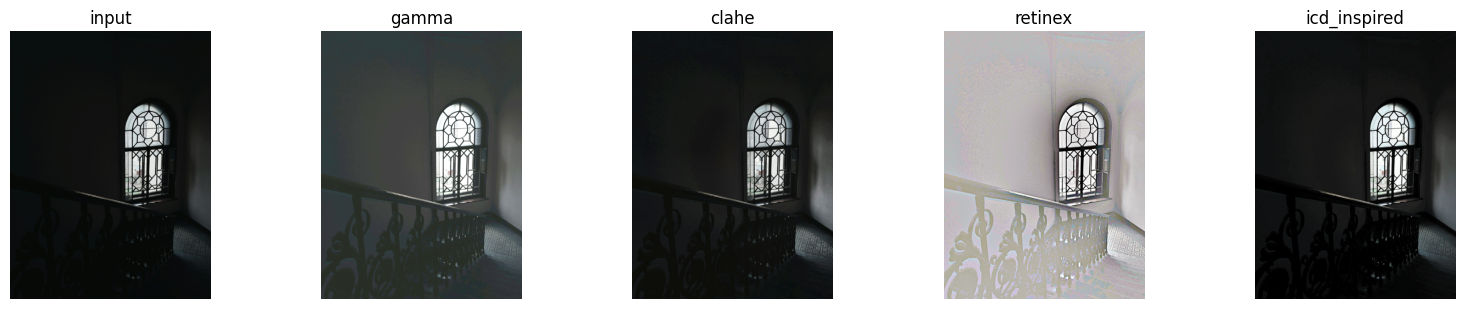

Saved outputs to: /work/write_blog/images/output
Saved grids to: /work/write_blog/images/grids


In [8]:
methods = {
    "input": lambda x: x,
    "gamma": lambda x: gamma_exposure(x, gamma=0.55, gain=1.15),
    "clahe": lambda x: clahe_lab(x, clip_limit=2.0, tile_grid_size=(8, 8)),
    "retinex": lambda x: multi_scale_retinex(x, sigmas=(15, 80, 250)),
    "icd_inspired": lambda x: icd_inspired_enhance(
        x,
        gamma=0.50,
        gain=1.10,
        dark_threshold=0.16,
        gate_sharpness=28.0,
        min_chroma_strength=0.35,
    ),
}

def make_grid(images, titles, cols=None, figsize_per_img=4):
    n = len(images)
    cols = cols or n
    rows = math.ceil(n / cols)
    plt.figure(figsize=(figsize_per_img * cols, figsize_per_img * rows))
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(np.clip(img, 0, 1))
        plt.axis("off")
        plt.title(title)
    plt.tight_layout()
    return plt.gcf()

all_results = {}

for path in tqdm(image_paths):
    img = read_rgb(path)
    results = {}
    for name, fn in methods.items():
        out = fn(img)
        results[name] = out
        save_rgb(OUT_DIR / name / path.name, out)

    all_results[path.name] = results

    fig = make_grid(
        [results[name] for name in methods.keys()],
        list(methods.keys()),
        cols=len(methods),
        figsize_per_img=3.2
    )
    grid_path = GRID_DIR / f"{path.stem}_grid.png"
    fig.savefig(grid_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Saved outputs to:", OUT_DIR.resolve())
print("Saved grids to:", GRID_DIR.resolve())


## 3. ノイズ・明るさ・色の簡易指標を見る

今回は正解画像がないため、PSNRやSSIMのような full-reference 指標は計算しません。

代わりに、画像を観察するための補助指標を出します。

| 指標 | 見ているもの | 注意点 |
|---|---|---|
| `mean_luma` | 平均輝度 | 明るさの目安。高いほど良いとは限りません |
| `std_luma` | 輝度のばらつき | コントラストの目安ですが、ノイズも含みます |
| `dark_10pct_luma_std` | 暗い10%領域の輝度標準偏差 | 暗部のばらつきの代理指標。ノイズそのものの厳密な測定ではありません |
| `mean_saturation` | 彩度平均 | 色の強さの目安。自然さとは別です |
| `clip_white_ratio` | 白飛びに近い画素の比率 | 窓やライトが飛んでいないかを見る補助 |
| `clip_black_ratio` | 黒つぶれに近い画素の比率 | 暗部が残りすぎていないかを見る補助 |

結果は `images/output/comparison_stats.csv` に保存します。これらの数値は絶対評価ではなく、図を見るための補助として扱います。


In [9]:
def simple_stats(img):
    img = np.clip(img, 0, 1)
    y = luminance(img)
    hsv = cv2.cvtColor(rgb_to_uint8(img), cv2.COLOR_RGB2HSV).astype(np.float32)
    sat = hsv[..., 1] / 255.0

    dark_mask = y < np.percentile(y, 10)
    dark_std = float(y[dark_mask].std()) if np.any(dark_mask) else 0.0

    return {
        "mean_luma": float(y.mean()),
        "std_luma": float(y.std()),
        "dark_10pct_luma_std": dark_std,
        "mean_saturation": float(sat.mean()),
        "clip_white_ratio": float((img >= 0.985).any(axis=-1).mean()),
        "clip_black_ratio": float((img <= 0.015).all(axis=-1).mean()),
    }

import pandas as pd

rows = []
for img_name, results in all_results.items():
    for method, img in results.items():
        row = {"image": img_name, "method": method}
        row.update(simple_stats(img))
        rows.append(row)

df = pd.DataFrame(rows)
display(df)

csv_path = OUT_DIR / "comparison_stats.csv"
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)


,image,method,mean_luma,std_luma,dark_10pct_luma_std,mean_saturation,clip_white_ratio,clip_black_ratio
0,pexels-octoptimist-3185041.jpg,input,0.092255,0.153777,0.006343,0.207562,0.000006,0.000375
1,pexels-octoptimist-3185041.jpg,gamma,0.270712,0.161761,0.026630,0.123058,0.030860,0.000007
2,pexels-octoptimist-3185041.jpg,clahe,0.122863,0.152355,0.010350,0.150340,0.000034,0.000107
3,pexels-octoptimist-3185041.jpg,retinex,0.689444,0.138752,0.180924,0.071663,0.013974,0.009154
4,pexels-octoptimist-3185041.jpg,icd_inspired,0.111708,0.183674,0.000000,0.062166,0.010762,0.195571


Saved: images/output/comparison_stats.csv


## 4. crop比較を作る

全体画像だけでは、暗部の持ち上がり方や色ムラの違いが分かりにくいことがあります。

ここでは同じ領域を切り出し、手法ごとの crop グリッドを作ります。記事の「結果2: 暗い部分を拡大して比べる」に使う図です。

出力先は次の通りです。

```text
images/crops/{image_stem}_crop_grid.png
```

暗部や窓周辺など、記事で注目したい場所がある場合は `CROP_BOXES` を画像ごとに指定してください。

```python
CROP_BOXES = {
    "pexels-octoptimist-3185041.jpg": (x, y, w, h),
}
```

未指定の場合は中央付近を自動で切り出します。


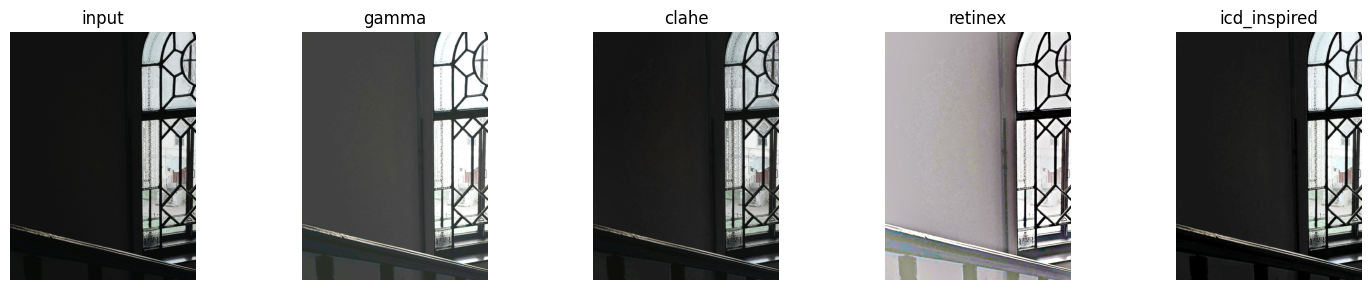

Saved crop grids to: /work/write_blog/images/crops


In [10]:
# 必要に応じて画像ごとに調整してください
# 未指定の画像は中央付近を自動で crop します。
CROP_BOXES = {
    # "room.jpg": (100, 100, 240, 180),
    # "neon.jpg": (200, 150, 240, 180),
}

def default_crop_box(img, frac=0.35):
    h, w = img.shape[:2]
    cw, ch = int(w * frac), int(h * frac)
    x = (w - cw) // 2
    y = (h - ch) // 2
    return x, y, cw, ch

def crop_img(img, box):
    x, y, w, h = box
    return img[y:y+h, x:x+w]

for img_name, results in all_results.items():
    base = results["input"]
    box = CROP_BOXES.get(img_name, default_crop_box(base))
    crops = [crop_img(results[name], box) for name in methods.keys()]

    fig = make_grid(crops, list(methods.keys()), cols=len(methods), figsize_per_img=3.0)
    crop_path = CROP_DIR / f"{Path(img_name).stem}_crop_grid.png"
    fig.savefig(crop_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Saved crop grids to:", CROP_DIR.resolve())


## 5. Intensity / Chromaticity を可視化する

ICDの考え方を説明するために、元画像を Intensity と Chromaticity に分けて可視化します。

この notebook では次のように計算します。

```text
Intensity = max(R, G, B)
Chromaticity = log(RGB / Intensity)
```

`Intensity` は、その画素がどれくらい明るいかを表す包絡です。明るい窓や壁は高く、暗い壁や階段は低くなります。

`Chromaticity` は、RGBの絶対値ではなくチャンネル間の相対比率です。ここで保存する `chromaticity visualization` は、人間が自然な色として見るための画像ではありません。画像内で色比率がどのように変わっているかを見るために、表示用に正規化した図です。

出力先は次の通りです。

| 出力 | 保存先 |
|---|---|
| Intensity画像 | `images/icd_components/{image_stem}_intensity.png` |
| Chromaticity可視化 | `images/icd_components/{image_stem}_chromaticity_vis.png` |
| 3枚並びの説明図 | `images/icd_components/{image_stem}_components.png` |


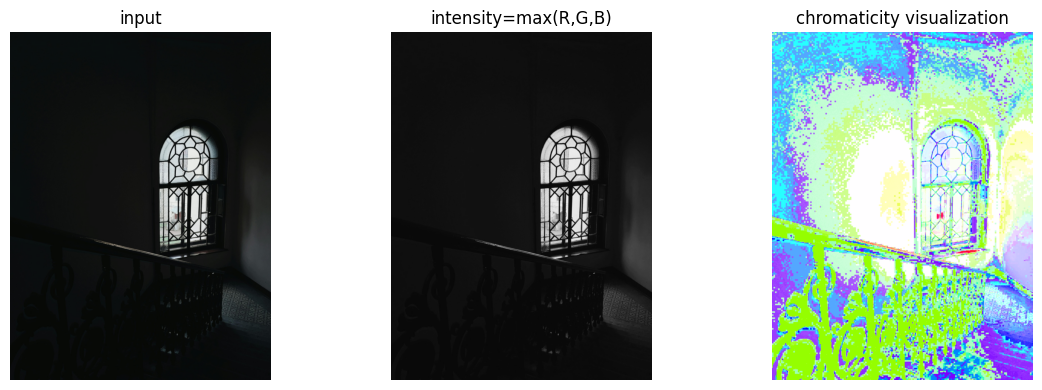

In [11]:
ICD_COMPONENT_DIR = Path("images/icd_components")
ICD_COMPONENT_DIR.mkdir(parents=True, exist_ok=True)

for path in image_paths:
    img = read_rgb(path)
    I, C_vis = visualize_icd_components(img)

    save_rgb(ICD_COMPONENT_DIR / f"{path.stem}_intensity.png", np.stack([I, I, I], axis=-1))
    save_rgb(ICD_COMPONENT_DIR / f"{path.stem}_chromaticity_vis.png", C_vis)

    fig = make_grid(
        [img, np.stack([I, I, I], axis=-1), C_vis],
        ["input", "intensity=max(R,G,B)", "chromaticity visualization"],
        cols=3,
        figsize_per_img=4
    )
    fig.savefig(ICD_COMPONENT_DIR / f"{path.stem}_components.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 6. 公式 ICDNet を実行する（任意・GPU推奨）

ここからは任意です。公式リポジトリ [mubaisam/ICD](https://github.com/mubaisam/ICD) の `test.py` を使って、学習済みICDNetの推論結果を作ります。

公式READMEでは、参照画像なしの direct inference として次の形式が案内されています。

```bash
python test.py --input_dir ./data/Test_Data --save_dir ./data/Results
```

この notebook のコードセルでは、次の処理を行います。

```text
1. `ICD/` がなければ公式リポジトリを clone する
2. `images/input/` の画像を `ICD/data/Test_Data/` にコピーする
3. `LOL_REAL_best_model.pth` を指定して `test.py` を実行する
4. 結果を `images/output/official_icd/` にコピーする
```

初期状態では `RUN_OFFICIAL_ICD = False` にしています。公式ICDNetを実行する場合は、次のコードセルの先頭を `True` に変更してください。

> 注意: 公式推論には PyTorch、torchvision、checkpoint ファイルが必要です。GPU環境を推奨します。リポジトリや重みファイルの配布条件は、公式リポジトリ側のREADMEとLICENSEを確認してください。


In [ ]:
# 公式 ICDNet を使う場合だけ True に変更してください。
RUN_OFFICIAL_ICD = False
if RUN_OFFICIAL_ICD:
    repo_dir = Path("ICD")
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/mubaisam/ICD.git"],
            check=True
        )

    # test.py / model.py の直接実行に必要な最低限の依存関係。
    def ensure_import(import_name: str, pip_name: str | None = None):
        pip_name = pip_name or import_name
        try:
            __import__(import_name)
            print(f"OK: {import_name}")
        except ModuleNotFoundError:
            print(f"Installing: {pip_name}")
            subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q", pip_name],
                check=True
            )

    ensure_import("numpy")
    ensure_import("PIL", "pillow")
    ensure_import("tqdm")
    ensure_import("einops")

    try:
        import torch
        import torchvision
        print("OK: torch / torchvision")
    except ModuleNotFoundError:
        print("Installing: torch / torchvision")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "torch", "torchvision"],
            check=True
        )

    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    icd_input = repo_dir / "data" / "Test_Data"
    icd_output = repo_dir / "data" / "Results"
    icd_input.mkdir(parents=True, exist_ok=True)
    icd_output.mkdir(parents=True, exist_ok=True)

    # 入力画像をコピー
    for p in image_paths:
        dst = icd_input / p.name
        shutil.copy2(p, dst)

    # test.py のデフォルトckptが存在しない場合があるため、実在するLOL_REALを明示指定する。
    ckpt = repo_dir / "weights" / "LOL_REAL_best_model.pth"
    if not ckpt.exists():
        print("Available weights:")
        for w in sorted((repo_dir / "weights").glob("*.pth")):
            print(" -", w.name)
        raise FileNotFoundError(f"Checkpoint not found: {ckpt}")

    gpu_id = "0"

    cmd = [
        sys.executable, "test.py",
        "--gpu_id", gpu_id,
        "--input_dir", "./data/Test_Data",
        "--save_dir", "./data/Results",
        "--ckpt", "./weights/LOL_REAL_best_model.pth",
    ]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=str(repo_dir), check=True)

    # 結果を notebook 側にもコピー
    OFFICIAL_ICD_DIR = OUT_DIR / "official_icd"
    OFFICIAL_ICD_DIR.mkdir(parents=True, exist_ok=True)

    input_stems = {p.stem for p in image_paths}
    copied = 0
    for p in icd_output.rglob("*"):
        if p.suffix.lower() in image_exts and p.stem in input_stems:
            shutil.copy2(p, OFFICIAL_ICD_DIR / p.name)
            copied += 1

    print(f"Official ICD outputs copied: {copied}")
    print("Official ICD outputs directory:", OFFICIAL_ICD_DIR.resolve())
else:
    print("RUN_OFFICIAL_ICD=False のため、公式 ICDNet は実行していません。")

RUN_OFFICIAL_ICD=False のため、公式 ICDNet は実行していません。


## 7. 公式 ICDNet 結果がある場合、比較グリッドに追加する

`images/output/official_icd/` に公式ICDNetの結果がある場合、通常の比較グリッドに `official_icd` を追加した図を作ります。

出力先は次の通りです。

```text
images/grids/{image_stem}_with_official_icd.png
```

記事の「結果4: 公式ICDNetも含めて比べる」には、この図を使います。

ここで大事なのは、`icd_inspired` と `official_icd` を混ぜて説明しないことです。

```text
icd_inspired:
  分解の考え方を説明するための簡易実装

official_icd:
  公式実装の学習済みモデルによる推論結果
```


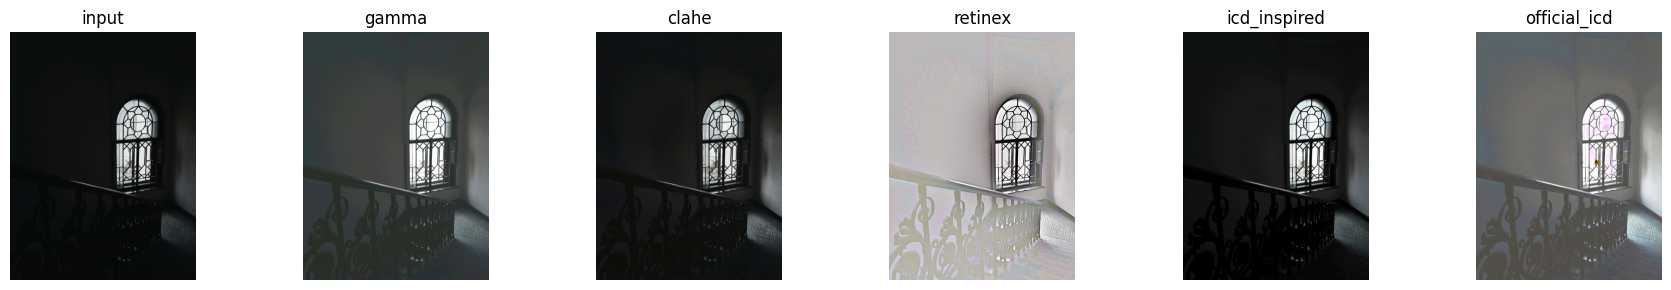

Saved: images/grids/pexels-octoptimist-3185041_with_official_icd.png


In [17]:
OFFICIAL_ICD_DIR = OUT_DIR / "official_icd"

if OFFICIAL_ICD_DIR.exists():
    for path in image_paths:
        candidates = list(OFFICIAL_ICD_DIR.glob(path.stem + ".*"))
        if not candidates:
            print("No official ICD result for:", path.name)
            continue

        official = read_rgb(candidates[0])
        results = dict(all_results[path.name])
        results["official_icd"] = official

        fig = make_grid(
            [results[name] for name in results.keys()],
            list(results.keys()),
            cols=len(results),
            figsize_per_img=3.0
        )
        out_path = GRID_DIR / f"{path.stem}_with_official_icd.png"
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print("Saved:", out_path)
else:
    print("公式ICDNet結果フォルダがありません。先に RUN_OFFICIAL_ICD=True で実行してください。")


## 8. 記事で使う図とファイル

この notebook で生成するファイルと、記事中の使いどころの対応です。

| 記事中の図・表 | notebookの出力 |
|---|---|
| 結果1: 画像全体での比較 | `images/grids/pexels-octoptimist-3185041_grid.png` |
| 結果2: 暗部cropの比較 | `images/crops/pexels-octoptimist-3185041_crop_grid.png` |
| 結果3: Intensity / Chromaticity可視化 | `images/icd_components/pexels-octoptimist-3185041_components.png` |
| 結果4: 公式ICDNetを含めた比較 | `images/grids/pexels-octoptimist-3185041_with_official_icd.png` |
| 簡易指標の表 | `images/output/comparison_stats.csv` |

公開記事では、`icd_inspired` は説明用、`official_icd` は公式モデルの推論結果として分けて書きます。また、正解画像がないため、この notebook の簡易指標は「どれが正しいか」を決めるものではなく、見た目の違いを読むための補助として扱います。
